<a href="https://colab.research.google.com/drive/11v2PuH4fpzYBWNLacubk8xci6-6C5vVd?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Multilayer Perceptron Regression for Predicting Hydrogen Storage in Metal-Organic Frameworks (MOFs)

Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo


**Learning objectives:**
- Understand how multilayer perceptrons approximate nonlinear structure-property relationships in nanoporous materials.
- Tune PyTorch MLP hyperparameters with k-fold cross validation and interpret learning curves.
- Interpret model predictions using SHAP to quantify feature importance in the context of nanoporous materials.


**References for the dataset:**
- Textural properties of MOFs (as features):
   - [MOFX-DB](https://mof.tech.northwestern.edu/databases#:~:text=Download%20Textural%20Properties)
   - N.S. Bobbitt, K. Shi, B.J. Bucior, H. Chen, N. Tracy-Amoroso, Z. Li, Y. Sun, J.H. Merlin, J.I. Siepmann, D.W. Siderius, and R.Q. Snurr, “MOFX-DB: An Online Database of Computational Adsorption Data for Nanoporous Materials,” J. Chem. Eng. Data 68(2), 483-498 (2023).
- Simulated hydrogen adsorption data (as labels):
    - C. Zheng, A. Gopalan, and K. Shi, “PoroNet: An Inherently Interpretable Pore Graph Neural Network for Prediction of Gas Adsorption in Metal-Organic Frameworks (to be published)”

**References & further readings for ML:**
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- [SHAP explainability documentation](https://shap.readthedocs.io/en/latest/)
- [Google crash course on neural networks](https://developers.google.com/machine-learning/crash-course/neural-networks)


## 0. Preparation
Let's select GPU device to accelerate our training in this notebook:

`Edit` -> `Notebook settings` -> select available GPU -> click `save`

## 1. Dataset

We investigate hydrogen adsorption capacity at cryogenic condition (77 K, 100 bar) for 2,000 metal-organic frameworks (MOFs). Each sample provides textural descriptors/features such as void fraction, surface area, and pore diameters. Our goal is to predict volumetric hydrogen uptake (g/L) using these descriptors.


### 1.1 Load and Preview the MOF Dataset

We pull the comma-separated file from Dropbox (cached locally after the first download) and inspect the first few rows. This dataset contains the following columns:

| Column name in CSV file | Full name                                           | Definition                                                                                  | Units     |
|--------------------------|-----------------------------------------------------|---------------------------------------------------------------------------------------------|-----------|
| MOF_Name                       | ID name of the MOF                                  | e.g., for `tobmof-10008` file, `10008` is the ID name.                                          |           |
| vf                       | Helium void fraction                           | Volumetric fraction of void space measured by He adsorption                                  | fraction  |
| sa_acc_m2g               | Accessible gravimetric surface area | Gravimetric surface area for accessible pores only                                           | m²/g      |
| sa_tot_m2g               | Total gravimetric surface area | Gravimetric surface area for both accessible and inaccessible pores                          | m²/g      |
| sa_acc_m2cm3             | Accessible volumetric surface area | Volumetric surface area for accessible pores only                                            | m²/cm³    |
| sa_tot_m2cm3             | Total volumetric surface area    | Volumetric surface area for both accessible and inaccessible pores                           | m²/cm³    |
| pld_A                      | Pore limiting diameter            | Largest probe that can cross the simulation cell in at least one dimension via a diffusive pathway | Å     |
| lcd_A                      | Largest cavity diameter               | Largest cavity size                                                                          | Å        |
| H2_Loading_77K_g/L              | Hydrogen uptake            | Predicted hydrogen adsorption amount in MOFs via GCMC simulations at 77 K, 100 bar      | g/L |



In [ ]:
import pandas as pd

# URL of our dataset
DATA_URL = "https://www.dropbox.com/scl/fi/0e5at214ox32spbm328e2/H2_MOF_textural.csv?rlkey=fuwlotia7lgo37te2guif5naj&st=cz1gh3o4&dl=1"

raw_df = pd.read_csv(DATA_URL, encoding="latin1")
print(f"Dataset shape: {raw_df.shape}")
raw_df.head()

**Feature engineering** is the process of transforming raw data into useful input variables, or "features", that improve the performance of machine learning models. This involves using domain knowledge to select, manipulate, and create new features from existing data, which makes it easier for algorithms to learn and make accurate predictions.

For MOFs, there are many other ways to engineer features, including topological descriptors, pore network graphs, energy-based features, and chemically informed fingerprints.

### 1.2 Data Quality Checks

Before modeling we confirm the dataset has no missing entries or duplicate rows that could bias learning.


In [ ]:
print(raw_df.isnull().sum())
print(f"Number of duplicate rows: {raw_df.duplicated().sum()}")

In [ ]:
print(raw_df.info())

### 1.3 Data Split

Let's split our data into training and test set, we will use 50/50 as suggested by the original research paper:

In [ ]:
from sklearn.model_selection import train_test_split

# data spliting into training and testing, set random state to ensure reproducibility
df_train, df_test = train_test_split(raw_df,train_size=0.5,test_size=0.5,random_state=100)

### 1.4 Feature Normalization/Standardization

Let's check scale of each feature using training set:

In [ ]:
df_train.describe()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Select only numerical columns for plotting histograms
numerical_cols = raw_df.select_dtypes(include=np.number).columns

# Set the style for the plots
sns.set_style("whitegrid")

# Create histograms for each numerical feature
raw_df[numerical_cols].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

It looks like all features follow a Gaussian like distribution, so let's scale all features using Z-score method (transforming to a distribution with 0 mean and unit variance):

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define feature columns and target variable
feature_columns = raw_df.columns.drop(['MOF_Name', 'H2_Loading_77K_g/L']).tolist()
target_column = 'H2_Loading_77K_g/L'

# Separate features and target variable for train and test sets
X_train = df_train[feature_columns]
y_train = df_train[target_column]
X_test = df_test[feature_columns]
y_test = df_test[target_column]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert y to numpy array
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## 2. Multilayer Perceptron (MLP)

We will build fully connected neural networks in [PyTorch](https://pytorch.org/) to learn nonlinear mappings from MOF textural descriptors to cryogenic hydrogen storage capacity.

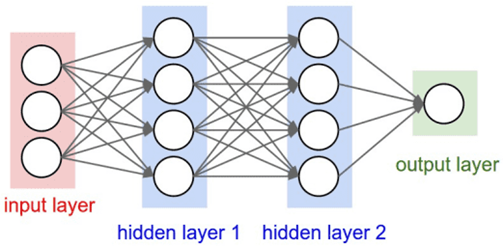



### 2.1 Define Our MLP Architecture Using PyTorch

Let's define a "blueprint" for MLP architecture using Python class.

A Python class is a way to group data and functions together so they represent a single concept or "blueprint" for creating objects. If you have never worked with classes before, think of them as templates: they define what kind of information an object will store and what it can do. See this [demo](https://colab.research.google.com/drive/1lCdUnY57RF-oy3l2t0RVHal0BDszMEGb?usp=sharing) for example.


In [ ]:
import torch
import torch.nn as nn

# Check if GPU is available and set device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


# Define the MLP Regressor model
# The new MLP class inherits all the data and behaviors (methods) from the parent class "nn.Module".
class MLP(nn.Module):

  def __init__(self, input_dim, hidden_dims=[128,64,32], dropout=0.2):
    """
    Initializes the MLP model. This is a special method called the constructor.
    It is automatically run when you create a new MLP object, allowing you to set its initial attributes.

    Args:
        self: Refers to the current instance of the class (convention).
              It allows you to access variables and methods associated with the current object.
        input_dim (int): The number of input features.
        hidden_dims (list): A list of integers specifying the number of neurons in each hidden layer.
                            By default set to 3 hidden layers with 128, 64, 32 neurons in each layer.
        dropout (float): The dropout probability. Default set to 0.2
    """

    # Set random seed for reproducibility
    torch.manual_seed(42)

    # Call the constructor of the parent class (nn.Module)
    super().__init__()

    # initialize layers list in our MLP
    layers = []
    in_dim = input_dim

    # Loop through the specified hidden layer dimensions to build the network
    for hidden_dim in hidden_dims:

      # Add a linear (fully connected) layer
      # Weights and biases are automatically initialized by PyTorch at this step
      layers.append(nn.Linear(in_dim, hidden_dim))
      layers.append(nn.ReLU()) # Use ReLU activation function to introduce non-linearity

      # Add dropout for regularization if dropout > 0
      if dropout > 0:
        layers.append(nn.Dropout(dropout))

      # Update input dimension for the next layer
      in_dim = hidden_dim

    # Output layer with a single neuron for regression output
    layers.append(nn.Linear(in_dim, 1))

    # Create an attribute (variable) called network that belongs to the current object
    # This keeps all the layers together as one sequential model, which PyTorch understands and can process.
    self.network = nn.Sequential(*layers)


  def forward(self, x):
    """
    It is a **requirement** to define the forward pass for any nn.Modules subclass (custom neural network).
    This forward method defines how the input data is processed through the network.

    Args:
      self: Refers to the current instance of the class.
      x (torch.Tensor): The input features.

    Returns:
      torch.Tensor: The output prediction.
    """

    # Pass the input through the defined network
    return self.network(x)

Now let's do a quick demo of the MLP class we just built.

In [ ]:
# determine input dim (number of features)
# 7 features/dimensions in our case
input_dim = X_train_scaled.shape[1]

# instantiate a small MLP for demonstration
# by default, we use 3 hidden layers defined in class and 0.2 dropout by default
my_mlp_model = MLP(input_dim=input_dim)
# move model to correct device (cuda/cpu)
my_mlp_model.to(device)

print(my_mlp_model)

In [ ]:
# Use the predict methods to do predictions for the first four samples in the training set
my_mlp_model.forward(torch.tensor(X_train_scaled[:4], dtype=torch.float32).to(device))

Our `my_mlp_model` instance also inherits properties and methods from the parent class `nn.Modules`. For example:

In [ ]:
# Inspect model state
print(my_mlp_model.state_dict())

# Switch between train/eval modes (inherited .train() and .eval())
my_mlp_model.eval()
print(f"After eval(): training flag = {my_mlp_model.training}")
my_mlp_model.train()
print(f"After train(): training flag = {my_mlp_model.training}")

### 2.2 Define Training Protocol

(Optional) Build a DataLoader helper to streamline the data pipeline, making it efficient to manage, prepare, and feed data to your PyTorch models during training and evaluation. (Especially useful when having a large dataset)

Key benefits of having a DataLoader are:

- Training stability: Shuffling prevents the model from learning patterns based on data order
- Memory management: Processing in batches allows you to work with datasets larger than your available RAM
- GPU utilization: Batched operations are much more efficient on GPUs than individual samples

By default, PyTorch assigns data points into batches without replacement.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Helper function to create a DataLoader
def make_loader(features, labels, batch_size=32, shuffle=True):
    """
    Creates a PyTorch DataLoader from features and labels.

    Args:
        features (np.ndarray): NumPy array of features.
        labels (np.ndarray): NumPy array of labels.
        batch_size (int): The batch size for the DataLoader.
        shuffle (bool): Whether to shuffle the data.

    Returns:
        torch.utils.data.DataLoader: The created DataLoader.
    """
    # Convert NumPy arrays to PyTorch tensors
    X = torch.tensor(features, dtype=torch.float32).to(device)
    y = torch.tensor(labels.reshape(-1,1), dtype=torch.float32).to(device)
    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

Now let's define our training protocol:

In [ ]:
from IPython.display import display
import plotly.graph_objects as go

# Function to train the model
def train_model(model, train_loader, val_loader, epochs=500, patience=10, lr=0.001, plot=True):
    """
    Trains the MLP model.

    Args:
        model: The MLP object/instance to be trained.
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data.
        epochs (int): Maximum number of epochs to train.
        patience (int): Number of epochs to wait for improvement in validation loss.
        lr: learning rate
        plot (bool): Whether to plot learning curves.

    Returns:
        dict: training and validation loss history
    """
    history = {"train_loss": [], "val_loss": []}

    # use the notebook's device (defined in an earlier cell)
    model.to(device)

    # let's use Adam optimizer and MSE loss for regression
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    if plot:
      # Initialize the figure outside the loop
      fig = go.FigureWidget(data=[
          go.Scatter(name='Train loss', mode='lines+markers',
                    hovertemplate='Epoch %{x}<br>Train: %{y:.4f}'),
          go.Scatter(name='Val loss', mode='lines+markers',
                    hovertemplate='Epoch %{x}<br>Val: %{y:.4f}')
      ])
      fig.update_layout(title='Training and Validation Loss',
                        xaxis_title='Epoch', yaxis_title='MSE Loss',
                        template='plotly_white', legend=dict(orientation="v"),
                        yaxis_type='log')
      display(fig)

    # Initialize early stopping state
    best_val = float("inf")
    best_state = None
    patience_counter = 0

    # start training loop
    for epoch in range(1, epochs + 1):

        # set model to training mode
        model.train()
        running_train = 0.0
        # loop over batches
        for x_train, y_train in train_loader:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
            # reset gradients
            optimizer.zero_grad()
            preds = model.forward(x_train)
            loss = criterion(preds, y_train)
            # backpropagation
            loss.backward()
            # update weights for this epoch/iteration
            optimizer.step()
            # accumulate training loss
            running_train += loss.item() * x_train.size(0)

        # calculate average training loss for the epoch
        train_loss = running_train / len(train_loader.dataset)

        # set the model to evaluation/prediction mode, so dropout layers are deactivated
        model.eval()
        running_val = 0.0
        # turn off gradient calculations for validation to save memory and computations
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device)
                preds = model.forward(x_val)
                loss = criterion(preds, y_val)
                running_val += loss.item() * x_val.size(0)

        # calculate average validation loss for the epoch
        val_loss = running_val / len(val_loader.dataset)

        # add losses to history for each epoch
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if plot:
          # update the figure with new loss values (in-place update)
          epochs_so_far = list(range(1, len(history["train_loss"]) + 1))
          with fig.batch_update():
              fig.data[0].x = epochs_so_far
              fig.data[0].y = history["train_loss"]
              fig.data[1].x = epochs_so_far
              fig.data[1].y = history["val_loss"]
              fig.layout.title = f"Training and Validation Loss (Epoch {epoch}/{epochs})"

        # Early stopping check
        if val_loss < best_val:
            best_val = val_loss
            # save best model state
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            # reset patience counter
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch} (best val {best_val:.6f})")
            break

    # Restore best weights (if any)
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

Here we used [PyTorch](https://pytorch.org/) to define the full process of training. Once you understand how it works at the fundamental level, you could use some high-level framework packages like [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) or [PyTorch Ignite](https://pytorch-ignite.ai/tutorials/beginner/01-getting-started/) to simplify and automate many processes with just a few lines of code.

### 2.3 A Quick Training, Learning Curve, and Early Stop
Now let's do a quick training of our MLP model using default setting for a MLP class. When you run the code cell, check the following:

- See how learning curve behaves
- See how early stopping works
- Change learning rate (`lr`) parameter to see its effect on training

In [ ]:
# Google colab can support third-party widgets such as dynamic plotting
from google.colab import output
output.enable_custom_widget_manager()

# Create a validation split from the training data (80/20 split)
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

# Create DataLoaders
train_loader = make_loader(X_subtrain, y_subtrain, batch_size=32, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=32, shuffle=False)

# instantiate a default MLP model
default_mlp = MLP(input_dim=input_dim)
default_mlp.to(device)

# train the my_mlp_model we instantiated earlier
# change lr to see the effect of learning rate
history = train_model(default_mlp, train_loader, val_loader, epochs=500, lr=0.001)

Let's evaluate the prediction on test set and draw a parity plot.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# set model to evaluation mode
default_mlp.eval()

# Convert test data to tensors and move to the correct device
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)

# Make predictions on the test set
with torch.no_grad():
    test_preds = default_mlp.forward(X_test_tensor).cpu().numpy().flatten()

# Calculate evaluation metrics
test_mse = mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R2: {test_r2:.4f}")

# Create a parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.6)
plt.plot([min(y_test.min(),test_preds.min()), max(y_test.max(),test_preds.max())],
         [min(y_test.min(),test_preds.min()), max(y_test.max(),test_preds.max())],
         'k--', lw=2)
plt.xlabel('True H2 Storage (g/L)')
plt.ylabel('Predicted H2 Storage (g/L)')
plt.title('Parity Plot: True vs Predicted H2 Storage (Test Set)')
plt.grid(True)
plt.show()

### 2.4 Hyperparameter Tuning via 3-Fold Cross Validation Using Optuna

Let's improve our model's performance by tuning the following MLP's hyperparameters:

- Number of hidden layers
- Number of neurons each layer

Each combination is evaluated with 3-fold cross validation on the training/validation split, tracking validation MSE. We will use [Optuna package](https://optuna.org/) to efficiently optimize hyperparameters.

Of course, the following code can be extended to tune other hyperparameters such as learning rate, dropout rate, activation function etc. Here we try to keep it simple.


Let's install `optuna` Python package first:

In [ ]:
!pip install optuna

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import KFold

# Define objective function to be optimized
# In Optuna, a trial is one attempt at training/evaluating your model with a particular set of hyperparameters.
def objective(trial):

    # how many hidden layers? Optuna will pick a integer between 3 and 5 (inclusive)
    n_layers = trial.suggest_int("n_layers", 3, 5)

    # build a list of hidden neurons, corresponding to number of layers pick
    # possible list could be [256,128,64] which is 3 layers each with 256, 128, 64 neurons
    hidden_dims = []
    for i in range(n_layers):
        units = trial.suggest_categorical(f"n_units_l{i+1}", [32, 64, 128, 256, 512])
        hidden_dims.append(units)

    # 3-fold CV
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_losses = []

    for tr_idx, va_idx in kf.split(X_train_scaled):
        X_tr, y_tr = X_train_scaled[tr_idx], y_train[tr_idx]
        X_va, y_va = X_train_scaled[va_idx], y_train[va_idx]

        # build a MLP model using the Optuna-selected hidden_dims
        model = MLP(input_dim=input_dim, hidden_dims=hidden_dims)
        train_loader = make_loader(X_tr, y_tr, shuffle=True)
        val_loader   = make_loader(X_va, y_va, shuffle=False)

        # reuse your training loop; keep default epochs, patience and lr, without plotting
        history = train_model(model, train_loader, val_loader, plot=False)

        fold_losses.append(min(history["val_loss"]))

    return float(np.mean(fold_losses))


In [ ]:
# Create an Optuna Study object (a container to keep all runs/results)
# Study will "minimize" the objective function
study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

### 2.5 Finalize the Model for Accelerated Materials Discovery

OK, now let's use the best hyperparameter set to rebuild a final MLP model.

In [ ]:
print("Best mean CV MSE:", study.best_value)
print("Best params:", study.best_params)

In [ ]:
# Train a final model with the best architecture and show the Plotly curve
best_hidden = [512,512, 256]
best_model = MLP(input_dim=input_dim, hidden_dims=best_hidden).to(device)

# train the best model
history = train_model(best_model, train_loader, val_loader, epochs=500, lr=0.001)

Let's evaluate the trained model:

In [ ]:
# set model to evaluation mode
best_model.eval()

# Make predictions on the test set
with torch.no_grad():
    test_preds = best_model.forward(X_test_tensor).cpu().numpy().flatten()

# Calculate evaluation metrics
test_mse = mean_squared_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R2: {test_r2:.4f}")

# Create a parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.6)
plt.plot([min(y_test.min(),test_preds.min()), max(y_test.max(),test_preds.max())],
         [min(y_test.min(),test_preds.min()), max(y_test.max(),test_preds.max())],
         'k--', lw=2)
plt.xlabel('True H2 Storage (g/L)')
plt.ylabel('Predicted H2 Storage (g/L)')
plt.title('Parity Plot: True vs Predicted H2 Storage (Test Set)')
plt.grid(True)
plt.show()

Comparison of evaluation metrics between default model and model that uses tuned hyperparameters:

| Model        | Test MSE | Test R²  |
|--------------|----------|----------|
| best_model   | 3.0370   | 0.9231   |
| default_mlp  | 5.6982   | 0.8558   |

Now let's estimate how fast the ML model makes the prediction:

In [ ]:
import time

num_predictions = 1000000
dummy_input = torch.randn(num_predictions, input_dim, device=device)

best_model.eval()

# Measure with synchronization
with torch.no_grad():
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    _ = best_model(dummy_input)

    if device.type == "cuda":
        torch.cuda.synchronize()
    end = time.perf_counter()

elapsed = end - start
print(f"Total time: {elapsed:.4f} s")
print(f"Throughput: {num_predictions/elapsed:.2f} preds/sec")
print(f"Avg per prediction: {(elapsed/num_predictions)*1e6:.2f} µs")

Now we have finalized the model, we can use it to rapidly screen a large amount of MOF structures for hydrogen storage applications.

Typically, before actual deployment, the best practice is to verify the **generalizability** of the model by testing it on small set of unseen structures from a different distribution (e.g., experimental structures or structures from another hypothetical database).

## 3. Feature Importance with SHAP

Extracting physical insights from ML models is equally important. We could use permutation importance or integrated gradients methods for extracting feature importance from neural network, but here we will introduce a state-of-the-art, general feature importance (explainable AI) method: **SHAP (SHapley Additive exPlanations)** method.




### 3.1 Basics

The SHAP method extends the concept of Shapley values from cooperative game theory, where the Shapley value measures feature importance based on the marginal contribution of each feature to the models' predictions.

That is to say, using the following [example](https://www.aidancooper.co.uk/how-shapley-values-work/), for *house1* what is the change in predicted price when a feature is added to the model? The marginal contributions of feature *A*, denoted in red as $MC_A$.

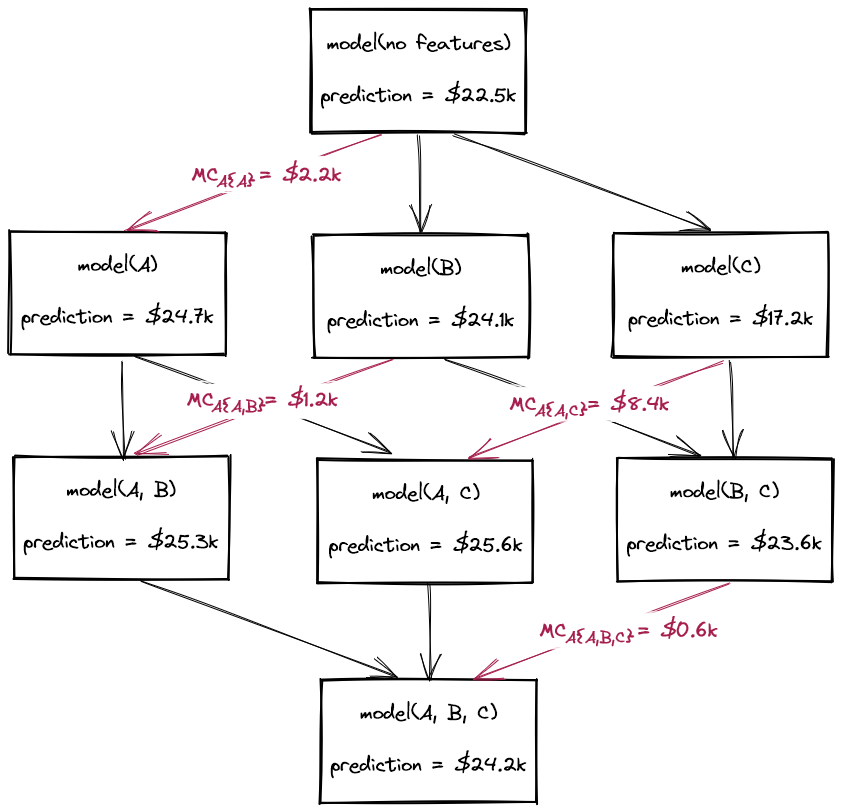

From these marginal contributions, we can calculate the Shapley value of feature *A* for *house1* as a weighted sum of the marginal contributions. The weights are the reciprocal of the count of connections at each layer. Note that the weights sum to 1.

$$
shapley_A(house1) = \tfrac{1}{3} \times 2200 + \tfrac{1}{6} \times 1200 + \tfrac{1}{6} \times 8400 + \tfrac{1}{3} \times 600
$$




Shapley values and SHAP values are often conflated, but they are not exactly the same. SHAP encompasses a range of techniques for efficiently approximating Shapley values. You can think of SHAP values represent a feature's responsibility for shifting the model output away from the baseline (average) prediction.

**Benefits of SHAP**:
- Model-agnostic: Works across tree models, linear models, and neural networks.
- Local interpretability: SHAP can explain why the model made a specific prediction by showing how much each feature pushed the prediction up or down.
- Global insights: By averaging SHAP values over many samples, we can see which features are most important overall in the model.
- Considers feature interactions, unlike simpler importance metrics.

### 3.2 Apply SHAP to Understand Feature Importance



Let's set up the DeepExplainer first, it is an efficient implementation of SHAP for deep learning models:

In [ ]:
!pip install shap==0.48.0

In [ ]:
import shap

# move model to cpu to avoid any surprise
best_model.cpu()
best_model.eval()

# Build background ("model with no features" reference distribution)
# This is what SHAP uses to define the baseline prediction.
# Using ALL training data as you requested (can be slow on big sets).
background = torch.tensor(X_train_scaled[:], dtype=torch.float32)

# Pick 200 random test rows to explain
# Journal quality usually requires thousands
n_test = X_test_scaled.shape[0]
idx = np.random.choice(n_test, size=200, replace=False)
explain_samples = torch.tensor(X_test_scaled[idx], dtype=torch.float32)

# Create the SHAP explainer
# DeepExplainer approximates the "add features and measure marginal contribution" idea
explainer = shap.DeepExplainer(best_model, background)

# Compute SHAP values for the selected test rows
shap_values = explainer.shap_values(explain_samples)

# Print a quick summary
# shape should be (num_explain_samples, n_features, n_model_output)
print("SHAP values array shape:", shap_values.shape)

To get an overview of which features are most important for a model we can plot the SHAP values of every feature for every sample. The plot below sorts features by the sum of SHAP value magnitudes over all samples, and uses SHAP values to show the distribution of the impacts each feature has on the model output.

In [ ]:
# Get feature names from df_train
feature_names = df_train.columns[1:8].tolist()

# summary plot
shap.summary_plot(shap_values[:,:,0], explain_samples, feature_names=feature_names)

Bar plot:

In [ ]:
shap.summary_plot(shap_values[:,:,0], explain_samples, feature_names=feature_names,
                  plot_type="bar", show=False)

Force plots show how each feature contributes to individual predictions.



In [ ]:
# Get the SHAP values and data for the selected sample
shap_values_sample = shap_values[0,:,0]
explain_data_sample = explain_samples[0,:].cpu().numpy()

# Display the force plot for the selected sample
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_sample, explain_data_sample, feature_names=feature_columns)

You can read more about different types of SHAP plots and how to interpret them: [Explaining Machine Learning Models: A Non-Technical Guide to Interpreting SHAP Analyses](https://www.aidancooper.co.uk/a-non-technical-guide-to-interpreting-shap-analyses/)